# **5-Prédiction du Churn**

In [73]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

In [48]:
data=pd.read_excel('data (3).xlsx')

In [49]:
data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1.0,1,5,159.93
1,50002,1,9,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0.0,1,3,120.90
2,50003,1,9,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0.0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0.0,1,3,134.07
4,50005,1,0,Phone,1,12,CC,Male,3,3,Mobile,5,Single,3,0,11,1.0,1,3,129.60


In [50]:
data.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

**5.2 Feature Engineering**

À partir de tes colonnes,  nous créerons :

⭐ 5.2.1 RFM

Recency = DaySinceLastOrder

Frequency = OrderCount

Monetary = CashbackAmount ou OrderAmountHikeFromlastYear

⭐ 5.2.2 Tendances et variations

% changement dépenses = OrderAmountHikeFromlastYear / Monetary précédent

% variation du nombre de coupons

⭐ 5.2.3 Indicateurs comportementaux

Panier moyen = (CashbackAmount / OrderCount)

Délai moyen entre commandes = Tenure / OrderCount

Intensité appli = HourSpendOnApp / DaySinceLastOrder

⭐ 5.2.4 Variables dérivées utiles

Client à forte distance = 1 si WarehouseToHome > seuil

Utilisation élevée app = 1 si HourSpendOnApp > médiane

⭐ 5.2.5 One-Hot Encoding

Pour : PreferredPaymentMode, Gender, PreferredLoginDevice, PreferedOrderCat…

In [51]:
#1) RFM
data= data.rename(columns={
    'DaySinceLastOrder' :'Recency',
    'OrderCount' :'Frequency',
    'CashbackAmount' :'Monetary'
})

# 2)Indicateurs comportementaux

# Panier
Panier_moyen=data['Monetary'] / (data['Frequency'] +1 )
data['Panier_moyen']=Panier_moyen

#Délai moyen entre commandes
Délai_moyen_entre_achats=data['Tenure'] / (data['Frequency'] +1)
data['Délai_moyen_entre_achats']=Délai_moyen_entre_achats

#Intensité appli
AppIntensity=data['HourSpendOnApp'] / (data['Recency'] + 1)
data['AppIntensity']=AppIntensity

#3)Variables de variation

# Variation % des dépenses
data["SpendVariation"] = data["OrderAmountHikeFromlastYear"] / (data["Monetary"] + 1)

# Fréquence normalisée (activité)
data["FreqVariation"] = data["Frequency"] / (data["Tenure"] + 1)


# 4) Création de Features binaires (flags)
# -------------------------------------------

# Longue inactivité (critère churn)
data["LongInactivity"] = (data["Recency"] >= 90).astype(int)

# Utilisation faible
median_app = data["HourSpendOnApp"].median()
data["LowAppUsage"] = (data["HourSpendOnApp"] < median_app).astype(int)

# Distance longue
dist_threshold = data["WarehouseToHome"].median()
data["FarFromWarehouse"] = (data["WarehouseToHome"] > dist_threshold).astype(int)

# Insatisfaction
data["Unsatisfied"] = (data["SatisfactionScore"] <= 2).astype(int)

#6) One-Hot Encoding
var_catégorielle=['PreferredPaymentMode', 'Gender', 'PreferredLoginDevice', 'PreferedOrderCat','MaritalStatus']
data = pd.get_dummies(data, columns=var_catégorielle, drop_first=True)

In [52]:
data.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_UPI,Gender_Male,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4,3,6,3,3,2,9,1,...,False,False,True,False,True,False,False,False,False,True
1,50002,1,9,1,8,3,4,3,7,1,...,True,True,True,False,False,True,False,False,False,True
2,50003,1,9,1,30,2,4,3,6,1,...,False,True,True,False,False,True,False,False,False,True
3,50004,1,0,3,15,2,4,5,8,0,...,False,True,True,False,True,False,False,False,False,True
4,50005,1,0,1,12,3,3,5,3,0,...,False,True,True,False,False,True,False,False,False,True


In [53]:
data = data.replace({True: 1, False: 0})

/tmp/ipython-input-3013327828.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({True: 1, False: 0})


In [54]:
data.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_UPI,Gender_Male,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4,3,6,3,3,2,9,1,...,0,0,1,0,1,0,0,0,0,1
1,50002,1,9,1,8,3,4,3,7,1,...,1,1,1,0,0,1,0,0,0,1
2,50003,1,9,1,30,2,4,3,6,1,...,0,1,1,0,0,1,0,0,0,1
3,50004,1,0,3,15,2,4,5,8,0,...,0,1,1,0,1,0,0,0,0,1
4,50005,1,0,1,12,3,3,5,3,0,...,0,1,1,0,0,1,0,0,0,1


## **5.3 Séparation Train/Test**

In [55]:
# ------------------------------------------
# 1. Variable cible (y)
# ------------------------------------------
y = data["Churn"]


# ------------------------------------------
# 2. Sélection des features numériques
# ------------------------------------------

numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "Complain",

    # Features dérivées RFM (utiliser les noms renommés)
    "Recency",
    "Frequency",
    "Monetary",

    # Features dérivées comportementales (utiliser les noms réels créés)
    "Panier_moyen",
    "Délai_moyen_entre_achats",
    "AppIntensity",

    # Variations
    "SpendVariation",
    "FreqVariation",

    # Flags
    "LongInactivity",
    "LowAppUsage",
    "FarFromWarehouse",
    "Unsatisfied"
]


# ------------------------------------------
# 3. Sélection des variables catégorielles encodées (One-Hot)
#    On prend automatiquement toutes les colonnes qui commencent par :
#    PreferredLoginDevice_, CityTier_, etc.
# ------------------------------------------

one_hot_features = [col for col in data.columns
                    if col.startswith("PreferredLoginDevice_")
                    or col.startswith("CityTier_")
                    or col.startswith("PreferredPaymentMode_")
                    or col.startswith("Gender_")
                    or col.startswith("PreferedOrderCat_")
                    or col.startswith("MaritalStatus_")]


# ------------------------------------------
# 4. Regrouper toutes les features
# ------------------------------------------

X = data[numeric_features + one_hot_features]

print("Nombre de variables utilisées :", X.shape[1])
print("Liste des features sélectionnées :")
print(X.columns.tolist())

Nombre de variables utilisées : 36
Liste des features sélectionnées :
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'Complain', 'Recency', 'Frequency', 'Monetary', 'Panier_moyen', 'Délai_moyen_entre_achats', 'AppIntensity', 'SpendVariation', 'FreqVariation', 'LongInactivity', 'LowAppUsage', 'FarFromWarehouse', 'Unsatisfied', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Male', 'PreferredLoginDevice_Phone', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [56]:

X_train , X_test ,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

# **Random Forest**

In [57]:
model_RF=RandomForestClassifier(n_estimators=100, random_state=42)
model_RF.fit(X_train, y_train)
y_pred_RF=model_RF.predict(X_test)

In [58]:
accuracy = accuracy_score(y_test, y_pred_RF)
recall = recall_score(y_test, y_pred_RF)
f1 = f1_score(y_test, y_pred_RF)
cm = confusion_matrix(y_test, y_pred_RF)

# Affichage
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nMatrice de confusion :")
print(cm)


Accuracy : 0.9778
Recall   : 0.8811
F1-score : 0.9288

Matrice de confusion :
[[938   3]
 [ 22 163]]


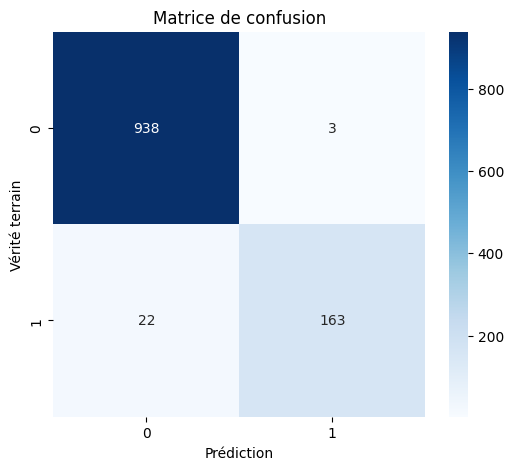

In [59]:
cm = confusion_matrix(y_test, y_pred_RF)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()

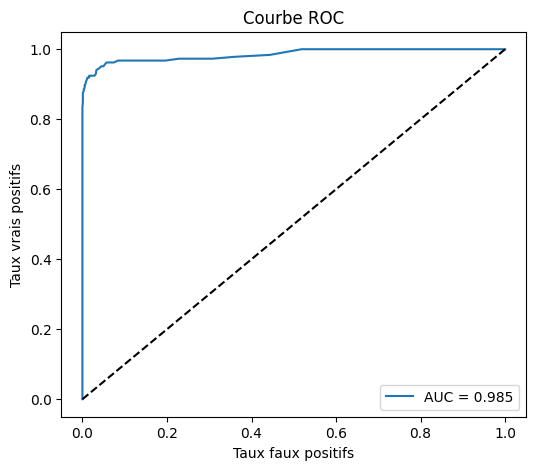

In [60]:
# Obtenir les probabilités prédites pour la classe 1 (churn)
y_probs = model_RF.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], 'k--')  # ligne diagonale
plt.xlabel('Taux faux positifs')
plt.ylabel('Taux vrais positifs')
plt.title('Courbe ROC')
plt.legend()
plt.show()


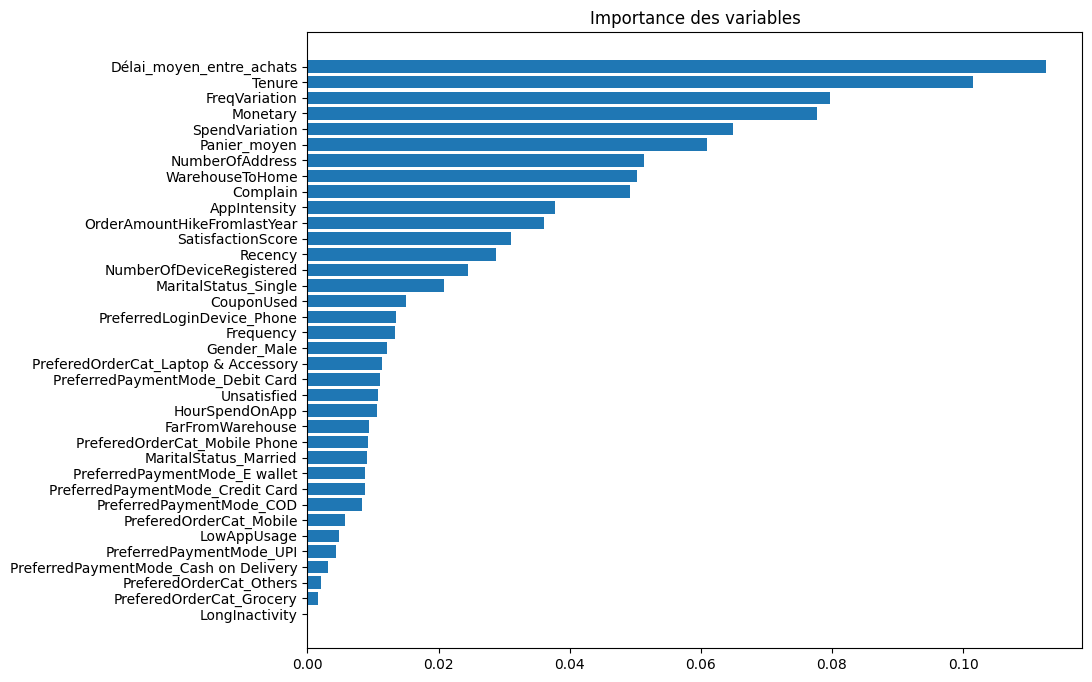

In [61]:
importances = model_RF.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,8))
plt.title('Importance des variables')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.gca().invert_yaxis()
plt.show()

# **Gradient Boosting**

In [62]:


model_GB = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_GB.fit(X_train, y_train)
y_pred_GB = model_GB.predict(X_test)



In [63]:


# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_GB)
recall = recall_score(y_test, y_pred_GB)
f1 = f1_score(y_test, y_pred_GB)
cm = confusion_matrix(y_test, y_pred_GB)

# Affichage
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nMatrice de confusion :")
print(cm)


Accuracy : 0.9636
Recall   : 0.8216
F1-score : 0.8812

Matrice de confusion :
[[933   8]
 [ 33 152]]


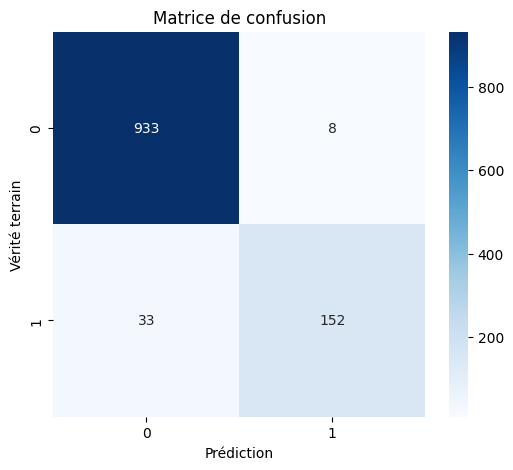

In [64]:

cm = confusion_matrix(y_test, y_pred_GB)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()


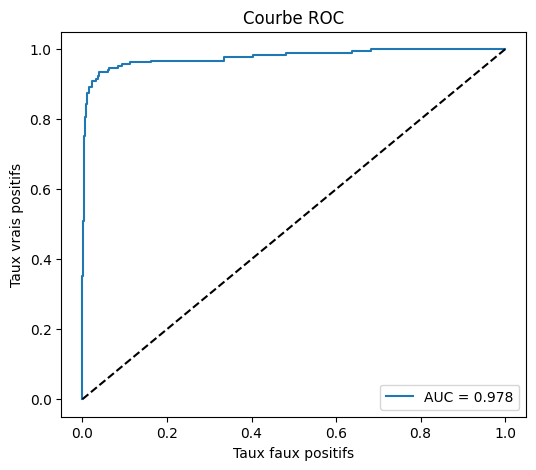

In [65]:
#Traceagade la courbe ROC
from sklearn.metrics import roc_curve, roc_auc_score

# Obtenir les probabilités prédites pour la classe 1 (churn)
y_probs = model_GB.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], 'k--')  # ligne diagonale
plt.xlabel('Taux faux positifs')
plt.ylabel('Taux vrais positifs')
plt.title('Courbe ROC')
plt.legend()
plt.show()


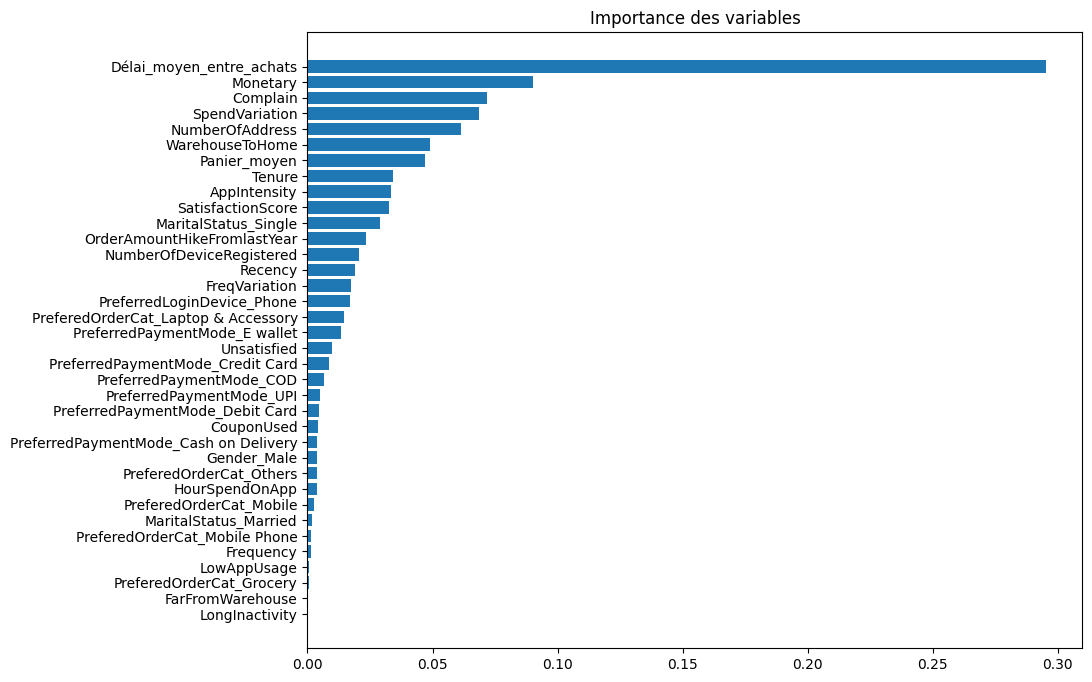

In [66]:
import numpy as np

importances = model_GB.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,8))
plt.title('Importance des variables')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.gca().invert_yaxis()
plt.show()


# **XGBoost**

In [67]:


model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

In [68]:
# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
cm = confusion_matrix(y_test, y_pred_xgb)

# Affichage
print(f"Accuracy : {accuracy:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nMatrice de confusion :")
print(cm)


Accuracy : 0.9574
Recall   : 0.8000
F1-score : 0.8605

Matrice de confusion :
[[930  11]
 [ 37 148]]


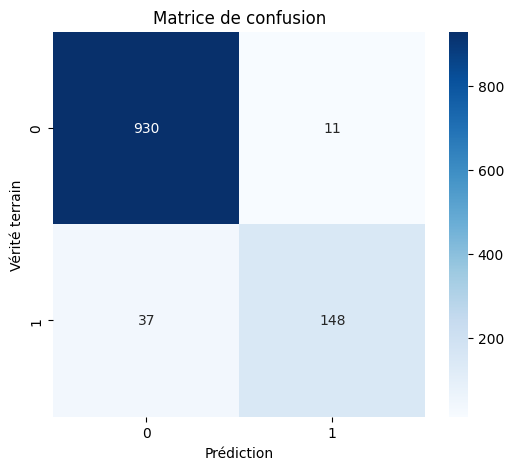

In [69]:

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()


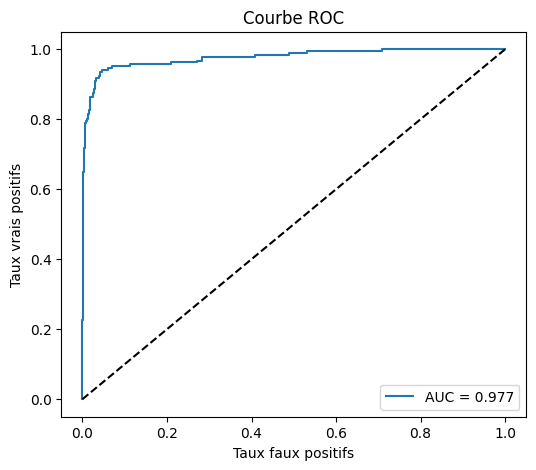

In [70]:
# Obtenir les probabilités prédites pour la classe 1 (churn)
y_probs = model_xgb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], 'k--')  # ligne diagonale
plt.xlabel('Taux faux positifs')
plt.ylabel('Taux vrais positifs')
plt.title('Courbe ROC')
plt.legend()
plt.show()


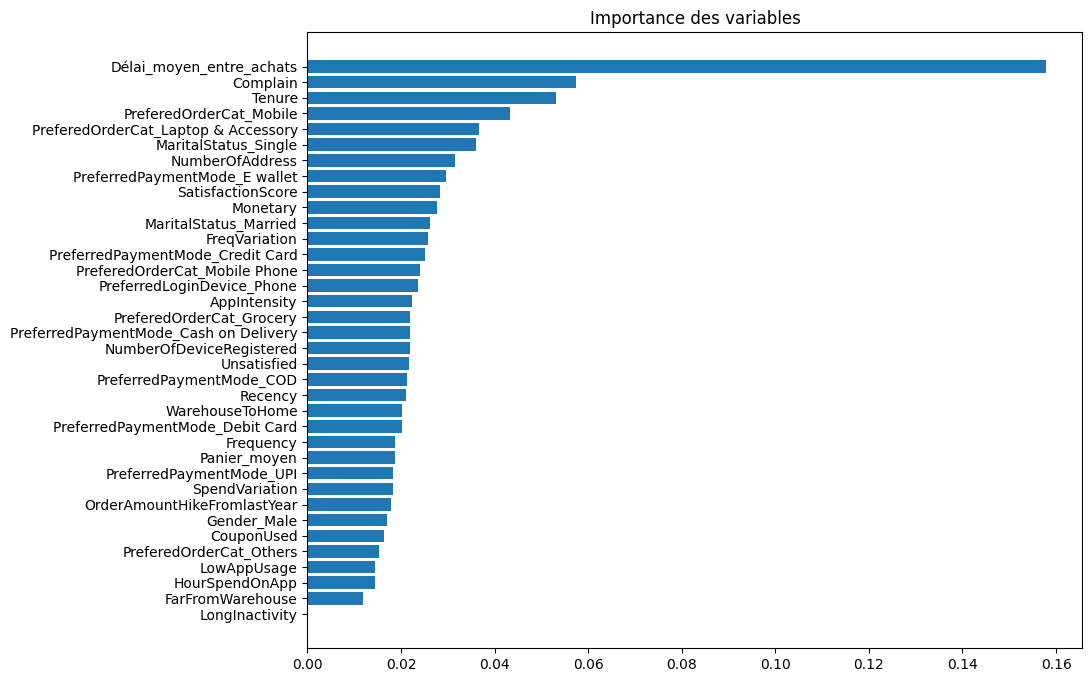

In [71]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,8))
plt.title('Importance des variables')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.gca().invert_yaxis()
plt.show()


D’après les métriques d’évaluation obtenues, le meilleur modèle pour la prédiction du churn est Random Forest. En effet, ce modèle présente une meilleure performance globale comparée au Gradient Boosting et à XGBoost, avec une précision (accuracy) plus élevée (97,78 % contre 96,36 % pour Gradient Boosting et 95,74 % pour XGBoost), un rappel (recall) supérieur (88,11 % contre 82,16 % pour Gradient Boosting et 80,00 % pour XGBoost) et un meilleur score F1 (92,88 % contre 88,12 % pour Gradient Boosting et 86,05 % pour XGBoost).

L’AUC, qui mesure la capacité du modèle à distinguer les classes, est également la plus élevée pour Random Forest (0,985 contre 0,978 pour Gradient Boosting et 0,977 pour XGBoost).

La matrice de confusion confirme ces résultats en montrant que Random Forest fait moins d’erreurs, notamment moins de faux négatifs, ce qui est crucial pour la détection efficace des clients susceptibles de churner.

Ainsi, en se basant sur ces indicateurs, Random Forest apparaît comme le modèle le plus adapté pour la prédiction du churn dans ce contexte, devant Gradient Boosting et XGBoost.

In [76]:
data['churn_pred'] = model_RF.predict(X)

In [77]:
data.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,Gender_Male,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,churn_pred
0,50001,1,4,3,6,3,3,2,9,1,...,0,1,0,1,0,0,0,0,1,1
1,50002,1,9,1,8,3,4,3,7,1,...,1,1,0,0,1,0,0,0,1,1
2,50003,1,9,1,30,2,4,3,6,1,...,1,1,0,0,1,0,0,0,1,1
3,50004,1,0,3,15,2,4,5,8,0,...,1,1,0,1,0,0,0,0,1,1
4,50005,1,0,1,12,3,3,5,3,0,...,1,1,0,0,1,0,0,0,1,1


In [78]:
data.to_csv('clients_avec_pred.csv', index=False)
